### Example 1a: Taylor series for a polynomial

In [1]:
from math import factorial, sin, cos, e
import numpy as np
import matplotlib.pyplot as plt

#Play around with Taylor series for a fourth order polynomial f(x)

def f(x):
    return 1/8*x**4 -1/6*x**3+1/2*x**2-1/2*x+2

#use the matplotlib library to plot this function. what is its general behavior?

In [2]:
#define functions for all of the derivatives of our polynomial

def f_1(x):
    return .5*x**3-.5*x**2+x-.5
def f_2(x):
    return 1.5*x**2-x+1
def f_3(x):
    return 3*x-1
def f_4(x):
    return 3

#put all of these derivatives together to form the Taylor series
def T(x,a):
    return f(a)+f_1(a)*(x-a)+f_2(a)/factorial(2) * (x-a)**2 + f_3(a)/factorial(3) * (x-a)**3 + f_4(a)/factorial(4) * (x-a)**4


#calculate the Taylor series estimate for x=1.5, using a Taylor series constructed around a=0.5
print('estimate for x=1.5 and a=.5: ',T(1.5,0.5))

#calculate the Taylor series estimate for x=1.5, using a Taylor series constructed around a=1
print('estimate for x=1.5 and a=1: ',T(1.5,1))

#calculate the analytical solution for f(1.5). how does this compare with our two estimates? which type(s) of error are we seeing?
print('true result for x=1.5: ', f(1.5))


#similar exercise for x=4
print('estimate for x=4 and a=1: ',T(4,1))
print('true result for x=4: ',f(4))

estimate for x=1.5 and a=.5:  2.4453125000000004
estimate for x=1.5 and a=1:  2.4453125
true result for x=1.5:  2.4453125
estimate for x=4 and a=1:  29.333333333333336
true result for x=4:  29.333333333333336


In [3]:
#try the linear approximation -- just 2 terms of the Taylor series:
def T_1(x,a):
    return f(a)+f_1(a)*(x-a)

#now reconsider the estimate for x=4, using truncated Taylor series constructed around a=.5,a=1 and a=3.5 
#How do results compare with the analytical solution? which type(s) of error do we have in this case?
print('true result for x=4: ',f(4))
print('estimate for x=4 and a=.5: ',T_1(4,.5))
print('estimate for x=4 and a=1: ',T_1(4,1))
print('estimate for x=4 and a=3.5: ',T_1(4,3.5))

#plot the truncated Taylor series, non-truncated Taylor series and original function using Matplotlib. 
#Compare the three functions. Where do they diverge?
#(analytical question) what is the quantitative error of the truncated Taylor series?

true result for x=4:  29.333333333333336
estimate for x=4 and a=.5:  1.6432291666666667
estimate for x=4 and a=1:  3.4583333333333335
estimate for x=4 and a=3.5:  27.143229166666668


Example 1b: Taylor series for a triginometric function

In [6]:
def g(x):
    return np.sin(x) + np.cos(x)

In [4]:
#construct a Taylor series for g(x) around a=0. Truncate this Taylor series after the first 5 terms.
#note that you may wish to use the known Maclauren series for sin(x) and cos(x) to do this.

def g_taylor(x, a=0):
    term0 = np.sin(a) + np.cos(a)
    term1 = (np.cos(a) - np.sin(a)) * (x - a)
    term2 = (-np.sin(a) - np.cos(a)) / factorial(2) * (x - a)**2
    term3 = (-np.cos(a) + np.sin(a)) / factorial(3) * (x - a)**3
    term4 = (np.sin(a) + np.cos(a)) / factorial(4) * (x - a)**4
    return term0 + term1 + term2 + term3 + term4

estimate for x=0.5 and a=0:  1.3567708333333335
true result for x=0.5:  1.3570081004945758

estimate for x=1 and a=0:  1.375
true result for x=1:  1.3817732906760363

estimate for x=2 and a=0:  0.33333333333333337
true result for x=2:  0.4931505902785393

estimate for x=4 and a=0:  -3.0
true result for x=4:  -1.4104461161715403



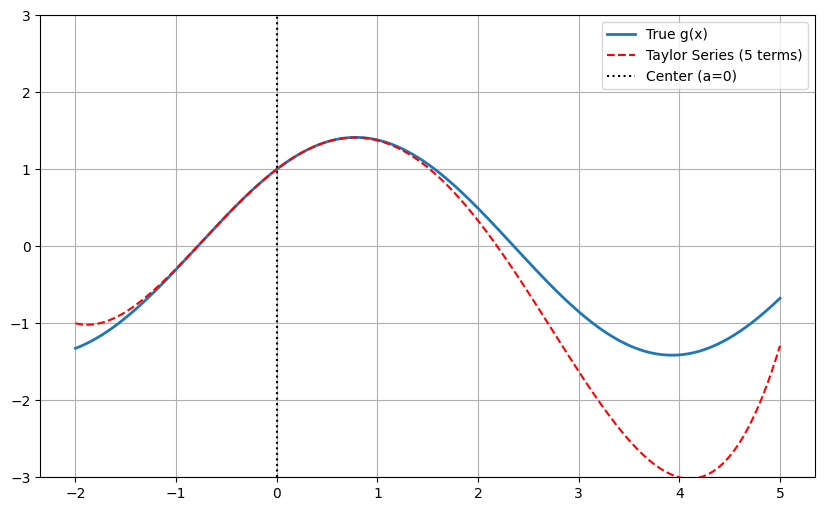

In [7]:
#calculate the estimated values for x=0.5,1,2,and 4 using your Taylor series. compare with the analytical values.
#plot the original function and your Taylor series. how quickly does the truncated series diverge from the true function?

test_points = [0.5, 1, 2, 4]
for x_val in test_points:
    true_val = g(x_val)
    est_val = g_taylor(x_val)

    print(f"estimate for x={x_val} and a=0:  {est_val}")
    print(f"true result for x={x_val}:  {true_val}")
    print()

xs = np.linspace(-2, 5, 500)
plt.figure(figsize=(10, 6))
plt.plot(xs, g(xs), label='True g(x)', linewidth=2)
plt.plot(xs, g_taylor(xs), '--', label='Taylor Series (5 terms)', color='red')
plt.axvline(x=0, color='black', linestyle=':', label='Center (a=0)')
plt.ylim(-3, 3)
plt.legend()
plt.grid(True)
plt.show()